# California Property Close Price Prediction

Predicting the final close price of single-family residential properties in
California using historical CRMLS (California Regional Multiple Listing Service)
transaction data.

**Program:** IDX Exchange — Data Science Internship



## Project Overview

The goal is to build a machine learning model that predicts the `ClosePrice`
(final sales price) of a single residential property in California based on its
characteristics (living area, bedrooms, bathrooms, lot size, location, etc.).

`ClosePrice` is the target variable. The dataset is restricted to:
- `PropertyType = "Residential"`
- `PropertySubType = "SingleFamilyResidence"`




---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

In [2]:
# find and filter files
file_list = glob.glob("Data/CRMLSSold*.csv")

clean_files = []
for sold in file_list:
    if "_filled" not in sold:
        clean_files.append(sold)

print(len(clean_files))
print(clean_files)

22
['Data/CRMLSSold202409.csv', 'Data/CRMLSSold202408.csv', 'Data/CRMLSSold202509.csv', 'Data/CRMLSSold202508.csv', 'Data/CRMLSSold202503.csv', 'Data/CRMLSSold202502.csv', 'Data/CRMLSSold202505.csv', 'Data/CRMLSSold202511.csv', 'Data/CRMLSSold202510.csv', 'Data/CRMLSSold202504.csv', 'Data/CRMLSSold202512.csv', 'Data/CRMLSSold202506.csv', 'Data/CRMLSSold202507.csv', 'Data/CRMLSSold202602.csv', 'Data/CRMLSSold202603.csv', 'Data/CRMLSSold202601.csv', 'Data/CRMLSSold202412.csv', 'Data/CRMLSSold202604.csv', 'Data/CRMLSSold202605.csv', 'Data/CRMLSSold202411.csv', 'Data/CRMLSSold202606.csv', 'Data/CRMLSSold202410.csv']


## 1. Load and Combine data

In [3]:
# Load all files 
df_list = []

# loop reads all 21 files one at a time, and store each resulting table into df_list
for file in clean_files:
    temp_df = pd.read_csv(file, low_memory = False)
    df_list.append(temp_df)
    
print(len(df_list))


# Combine separate tables into one table
df = pd.concat(df_list, ignore_index = True)
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())


22
Shape: (479358, 78)

Columns: ['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount', 'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric', 'ListingId', 'BathroomsTotalInteger', 'City', 'TaxYear', 'BuildingAreaTotal', 'BedroomsTotal', 'ContractStatusC

In [4]:
# Apply the dual filter (PropertyType + PropertySubType)

print('PropertyType value counts:')
print(df['PropertyType'].value_counts())

print('\nPropertySubType value counts:')
print(df['PropertySubType'].value_counts())


df = df[(df['PropertyType'] == 'Residential') & (df['PropertySubType'] == 'SingleFamilyResidence')]
print('Filtered shape:', df.shape)



PropertyType value counts:
PropertyType
Residential            323696
ResidentialLease       109527
Land                    14771
ResidentialIncome       13074
ManufacturedInPark      12593
CommercialSale           2940
CommercialLease          2458
BusinessOpportunity       299
Name: count, dtype: int64

PropertySubType value counts:
PropertySubType
SingleFamilyResidence    294407
Condominium               82466
Townhouse                 27528
Apartment                 11428
Duplex                     9240
ManufacturedOnLand         4904
Triplex                    2998
Quadruplex                 2940
StockCooperative           1573
MixedUse                   1552
Office                     1269
Retail                      844
Industrial                  516
Cabin                       431
Studio                      363
Business                    326
RoomingHouse                285
Warehouse                   239
SpecialPurpose              120
MultiFamily                 118
BoatSli

In [5]:
# Check missing values across key columns

# count null val in the whole dataset
df_missing = df.isnull().sum().sum()
print('Total missing values in dataset:', df_missing)

# check only specific cols 
key_cols = ['ClosePrice', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet']
print('\nMissing values in key columns:')
print(df[key_cols].isnull().sum())

Total missing values in dataset: 5642699

Missing values in key columns:
ClosePrice                  1
LivingArea                125
BedroomsTotal               0
BathroomsTotalInteger      27
LotSizeSquareFeet        4163
dtype: int64


989500000.0
179471    989500000.0
216403    970000000.0
263309    900000000.0
45902     875000000.0
52579     835800000.0
63184     815000000.0
384387    796000000.0
383496    768500000.0
47286     751412000.0
168771    740000000.0
Name: ClosePrice, dtype: float64


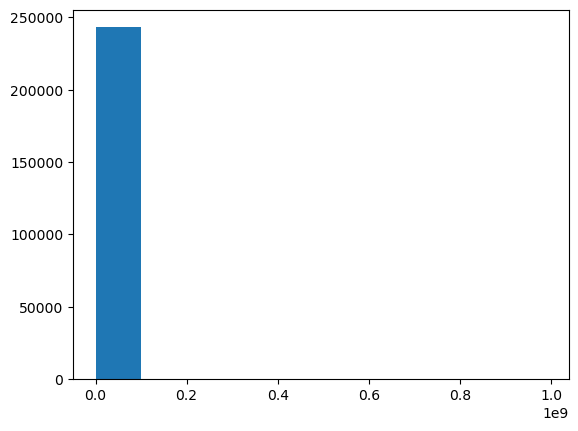

In [6]:
# Plot distributions for ClosePrice (decimal)
print(df['ClosePrice'].max())
print(df['ClosePrice'].sort_values(ascending=False).head(10))

plt.hist(df['ClosePrice'])
plt.show()


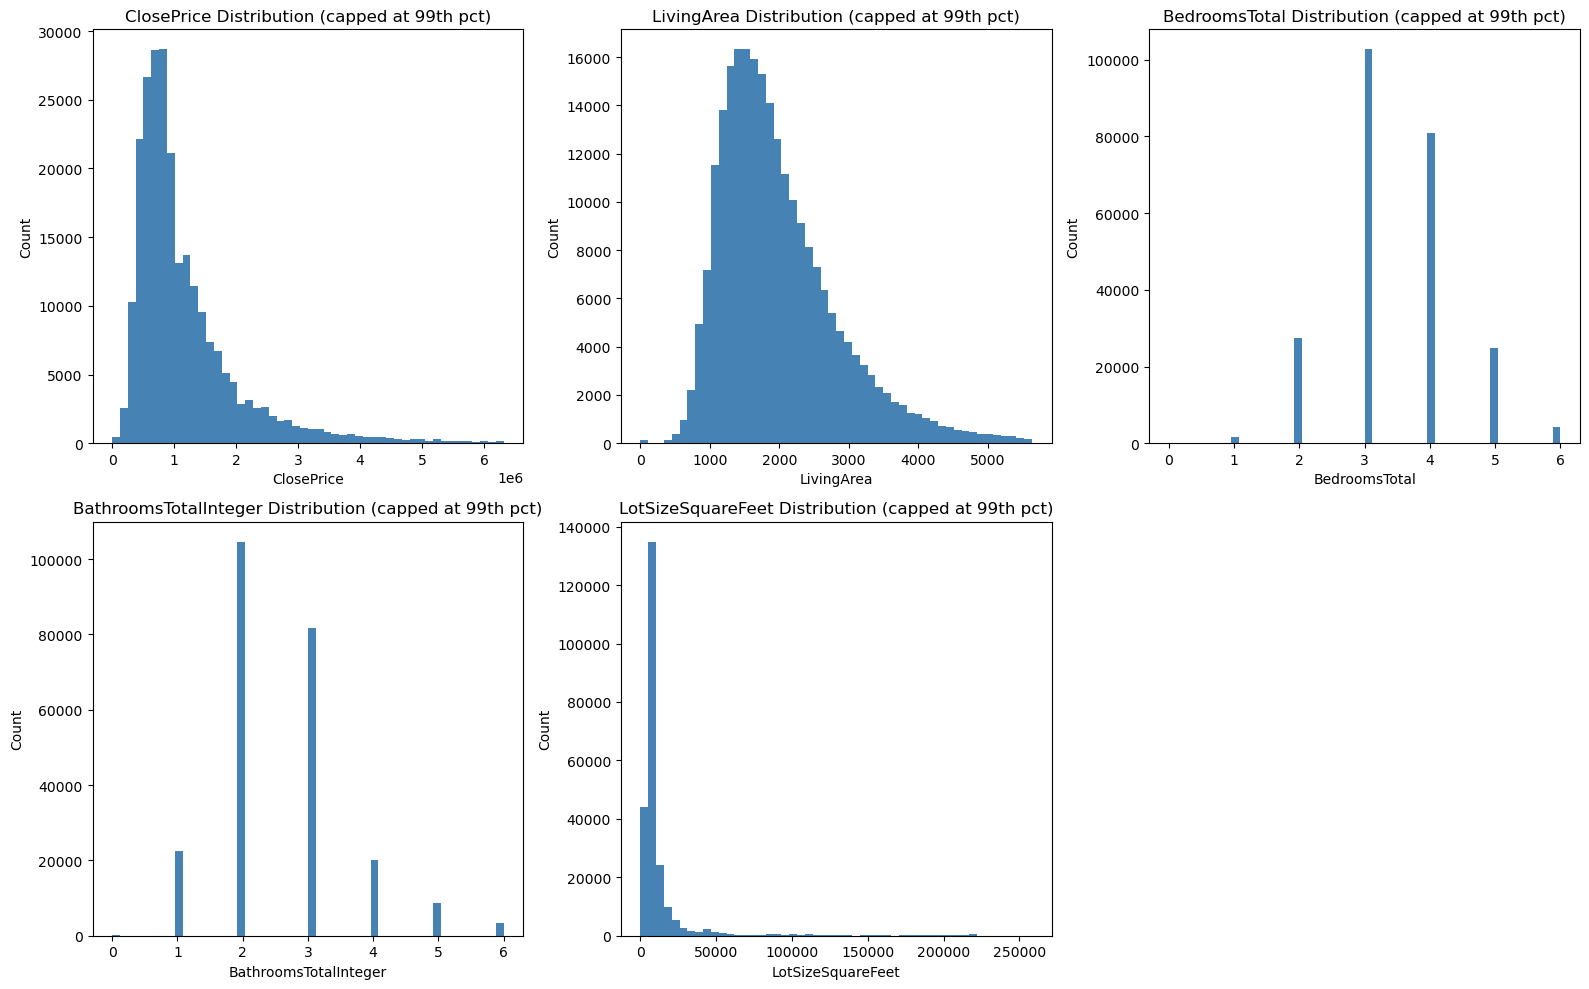

In [7]:
# Plot distributions for ClosePrice (decimal), LivingArea (decimal), Bedrooms, Bathrooms, LotSize

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

features = ['ClosePrice', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet']

for i, col in enumerate(features):
    data = df[col].dropna()
    upper = data.quantile(0.99)
    axes[i].hist(data, bins=50, range=(0, upper), color='steelblue', edgecolor='none')
    axes[i].set_title(f'{col} Distribution (capped at 99th pct)')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

axes[5].set_visible(False)
plt.tight_layout()
plt.show()

- ClosePrice: Right-skewed, peak around $600-$900k, long tail strtching toward $6M+.

- LivingArea: most home cluster around 1,500-2,500 sqft., tapering off toward larger homes.

- BedroomsTotak: discrete, not continous and peak at 3 and 4, which match single-family homes.

- BathroomsTotalInteger: discrete and peak at 2 and 3.

- LotsizeSquareFeet: most extreme skewed of all, huge spike near zero, then a long thin tail.



In [8]:
print('Top 5 ClosePrice values:')
print(df['ClosePrice'].nlargest(5))

print('\nTop 5 LotSizeSquareFeet values:')
print(df['LotSizeSquareFeet'].nlargest(5))

Top 5 ClosePrice values:
179471    989500000.0
216403    970000000.0
263309    900000000.0
45902     875000000.0
52579     835800000.0
Name: ClosePrice, dtype: float64

Top 5 LotSizeSquareFeet values:
92714     2.087221e+09
157594    1.938943e+09
64213     1.897474e+09
302892    1.897474e+09
325178    1.897474e+09
Name: LotSizeSquareFeet, dtype: float64


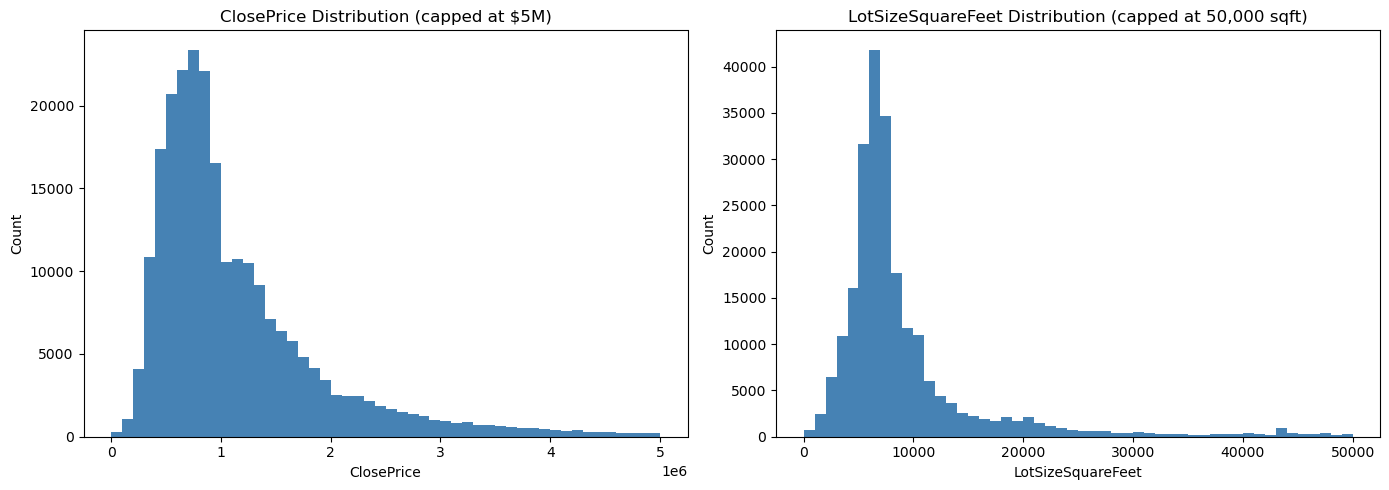

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cap ClosePrice at $5M for viewing
price_capped = df[df['ClosePrice'] < 5000000]['ClosePrice']
axes[0].hist(price_capped, bins=50, color='steelblue', edgecolor='none')
axes[0].set_title('ClosePrice Distribution (capped at $5M)')
axes[0].set_xlabel('ClosePrice')
axes[0].set_ylabel('Count')

# Cap LotSize at 50,000 sqft for viewing
lot_capped = df[df['LotSizeSquareFeet'] < 50000]['LotSizeSquareFeet']
axes[1].hist(lot_capped, bins=50, color='steelblue', edgecolor='none')
axes[1].set_title('LotSizeSquareFeet Distribution (capped at 50,000 sqft)')
axes[1].set_xlabel('LotSizeSquareFeet')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [10]:
# import glob

# Get all CSV files except the flagged _filled one
all_files = glob.glob('data/CRMLSSold*.csv')
all_files = [f for f in all_files if '_filled' not in f]

print(f'Found {len(all_files)} files to load:')
for f in sorted(all_files):
    print(' ', f)

Found 22 files to load:
  data/CRMLSSold202408.csv
  data/CRMLSSold202409.csv
  data/CRMLSSold202410.csv
  data/CRMLSSold202411.csv
  data/CRMLSSold202412.csv
  data/CRMLSSold202502.csv
  data/CRMLSSold202503.csv
  data/CRMLSSold202504.csv
  data/CRMLSSold202505.csv
  data/CRMLSSold202506.csv
  data/CRMLSSold202507.csv
  data/CRMLSSold202508.csv
  data/CRMLSSold202509.csv
  data/CRMLSSold202510.csv
  data/CRMLSSold202511.csv
  data/CRMLSSold202512.csv
  data/CRMLSSold202601.csv
  data/CRMLSSold202602.csv
  data/CRMLSSold202603.csv
  data/CRMLSSold202604.csv
  data/CRMLSSold202605.csv
  data/CRMLSSold202606.csv


In [11]:
import glob

file_list = glob.glob("data/CRMLSSold*.csv")
print(len(file_list))
print(file_list)

23
['data/CRMLSSold202409.csv', 'data/CRMLSSold202408.csv', 'data/CRMLSSold202501_filled.csv', 'data/CRMLSSold202509.csv', 'data/CRMLSSold202508.csv', 'data/CRMLSSold202503.csv', 'data/CRMLSSold202502.csv', 'data/CRMLSSold202505.csv', 'data/CRMLSSold202511.csv', 'data/CRMLSSold202510.csv', 'data/CRMLSSold202504.csv', 'data/CRMLSSold202512.csv', 'data/CRMLSSold202506.csv', 'data/CRMLSSold202507.csv', 'data/CRMLSSold202602.csv', 'data/CRMLSSold202603.csv', 'data/CRMLSSold202601.csv', 'data/CRMLSSold202412.csv', 'data/CRMLSSold202604.csv', 'data/CRMLSSold202605.csv', 'data/CRMLSSold202411.csv', 'data/CRMLSSold202606.csv', 'data/CRMLSSold202410.csv']


In [12]:
dfs = []

for file in sorted(all_files):
    temp_df = pd.read_csv(file, low_memory=False)
    temp_filtered = temp_df[(temp_df['PropertyType'] == 'Residential') & 
                              (temp_df['PropertySubType'] == 'SingleFamilyResidence')]
    dfs.append(temp_filtered)
    print(f'{file}: {temp_df.shape[0]} total rows -> {temp_filtered.shape[0]} after filter')

df_all = pd.concat(dfs, ignore_index=True)
print(f'\nCombined shape: {df_all.shape}')


data/CRMLSSold202408.csv: 24558 total rows -> 12433 after filter
data/CRMLSSold202409.csv: 21267 total rows -> 10909 after filter
data/CRMLSSold202410.csv: 23274 total rows -> 12347 after filter
data/CRMLSSold202411.csv: 20279 total rows -> 10692 after filter
data/CRMLSSold202412.csv: 20241 total rows -> 10624 after filter
data/CRMLSSold202502.csv: 18702 total rows -> 8851 after filter
data/CRMLSSold202503.csv: 21445 total rows -> 10610 after filter
data/CRMLSSold202504.csv: 23262 total rows -> 11880 after filter
data/CRMLSSold202505.csv: 23154 total rows -> 11777 after filter
data/CRMLSSold202506.csv: 22883 total rows -> 11701 after filter
data/CRMLSSold202507.csv: 23646 total rows -> 12114 after filter
data/CRMLSSold202508.csv: 22972 total rows -> 11454 after filter
data/CRMLSSold202509.csv: 22443 total rows -> 11456 after filter
data/CRMLSSold202510.csv: 23233 total rows -> 12029 after filter
data/CRMLSSold202511.csv: 19088 total rows -> 9739 after filter
data/CRMLSSold202512.csv: 2

In [13]:
key_cols = ['ClosePrice', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet', 'YearBuilt']

print('Missing values in combined dataset:')
print(df_all[key_cols].isnull().sum())

print('\nMissing as % of total:')
print((df_all[key_cols].isnull().sum() / len(df_all) * 100).round(2))

Missing values in combined dataset:
ClosePrice                  1
LivingArea                125
BedroomsTotal               0
BathroomsTotalInteger      27
LotSizeSquareFeet        4163
YearBuilt                 176
dtype: int64

Missing as % of total:
ClosePrice               0.00
LivingArea               0.05
BedroomsTotal            0.00
BathroomsTotalInteger    0.01
LotSizeSquareFeet        1.71
YearBuilt                0.07
dtype: float64


In [14]:
df_all[df_all['ClosePrice'].isnull()][['ListingId', 'CloseDate', 'City', 'ClosePrice', 'MlsStatus']]

,ListingId,CloseDate,City,ClosePrice,MlsStatus
54142,MC24191255,2024-12-13,Tracy,NaN,Closed
